# Model Versioning & Drift Detection — Solutions

**Module**: Production & Deployment | **Notebook 05 Solutions**  
**Level**: Intermediate

---

In [1]:
# Standard libraries
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# PanelBox imports
# Tutorial utilities
import sys

from panelbox.gmm import DifferenceGMM
from panelbox.models.static.pooled_ols import PooledOLS
from panelbox.production import ModelRegistry, PanelPipeline

sys.path.insert(0, str(Path("..").resolve()))
from utils import plot_coefficient_drift, set_production_style

# Visualization configuration
set_production_style()
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
REGISTRY_DIR = OUTPUT_DIR / "registry"

for d in [FIGURES_DIR, REGISTRY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


In [2]:
# Load datasets
df_firms = pd.read_csv(DATA_DIR / "firm_panel.csv")
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")

print(f"Firms: {df_firms.shape}, Years: {df_firms['year'].min()}-{df_firms['year'].max()}")
print(f"LGD:   {df_lgd.shape}, Months: {df_lgd['month'].min()}-{df_lgd['month'].max()}")

Firms: (2000, 7), Years: 2000-2019
LGD:   (3000, 7), Months: 1-15


---

## Exercise 1 (Easy): Create a Registry with 3 Versions

**Task**: Create a registry with 3 versions of a `PooledOLS` model, each trained on expanding time windows:
1. `v1`: Firm data 2000-2010
2. `v2`: Firm data 2000-2015
3. `v3`: Firm data 2000-2019

Use formula: `investment ~ value + capital + sales`

After registering all three, list the versions and load the latest one. Print its coefficients.

In [3]:
# Clean up any previous run
ex1_reg_dir = REGISTRY_DIR / "ex1_firm_ols"
if ex1_reg_dir.exists():
    shutil.rmtree(ex1_reg_dir)

# Create registry
ex1_registry = ModelRegistry(ex1_reg_dir)
print(f"Registry created at: {ex1_reg_dir}")

Registry created at: ../outputs/registry/ex1_firm_ols


In [4]:
# Define the training periods and version names
versions_config = [
    {"version": "v1", "max_year": 2010, "notes": "Trained on 2000-2010"},
    {"version": "v2", "max_year": 2015, "notes": "Trained on 2000-2015"},
    {"version": "v3", "max_year": 2019, "notes": "Trained on 2000-2019"},
]

model_params = {
    "formula": "investment ~ value + capital + sales",
    "entity_col": "firm_id",
    "time_col": "year",
}

# Train and register each version
for cfg in versions_config:
    df_train = df_firms[df_firms["year"] <= cfg["max_year"]].copy()

    pipeline = PanelPipeline(
        model_class=PooledOLS,
        model_params=model_params,
        name="Firm Investment OLS",
        description=f"PooledOLS {cfg['notes']}",
    )
    pipeline.fit(df_train)

    ex1_registry.register(
        pipeline,
        version=cfg["version"],
        notes=cfg["notes"],
    )

    print(f"{cfg['version']} ({cfg['notes']}): {df_train.shape[0]} obs")
    print(f"  Coefficients: {pipeline.results.params.to_dict()}")
    print()

v1 (Trained on 2000-2010): 1100 obs
  Coefficients: {'Intercept': -0.6146568788622757, 'value': 0.31168786025039547, 'capital': 0.27802879426661053, 'sales': 0.1751793958665627}

v2 (Trained on 2000-2015): 1600 obs
  Coefficients: {'Intercept': -0.5838035262681375, 'value': 0.3028235666577428, 'capital': 0.2861545547710391, 'sales': 0.16932735685214806}

v3 (Trained on 2000-2019): 2000 obs
  Coefficients: {'Intercept': -0.5074050147613818, 'value': 0.2990451388362428, 'capital': 0.2772938152703679, 'sales': 0.1674205188052195}



In [5]:
# List all versions
print("Registry Versions:")
print("=" * 60)
for v in ex1_registry.list_versions():
    print(f"  {v['version']}: {v['timestamp'][:19]}")
    print(f"    Notes: {v['notes']}")
    print(f"    Obs: {v.get('nobs', 'N/A')}, Params: {v.get('n_params', 'N/A')}")
    print()

Registry Versions:
  v1: 2026-02-22T15:59:31
    Notes: Trained on 2000-2010
    Obs: 1100, Params: 4

  v2: 2026-02-22T15:59:31
    Notes: Trained on 2000-2015
    Obs: 1600, Params: 4

  v3: 2026-02-22T15:59:31
    Notes: Trained on 2000-2019
    Obs: 2000, Params: 4



In [6]:
# Load the latest version
latest = ex1_registry.load_latest()
print(f"Latest version: {latest}")
print("\nCoefficients:")
print(latest.results.params)

Latest version: PanelPipeline(name='Firm Investment OLS', model=PooledOLS, fitted)

Coefficients:
Intercept   -0.5074
value        0.2990
capital      0.2773
sales        0.1674
dtype: float64


**Key takeaway**: The `ModelRegistry` makes it simple to maintain an expanding history of model versions. Each version preserves the full fitted pipeline, allowing you to load any past version for comparison or rollback.

---

## Exercise 2 (Medium): Implement a Drift Detection Function

**Task**: Write a function `detect_drift(registry, threshold=10)` that:
1. Loads the two most recent versions from the registry
2. Compares them using `.compare()`
3. Returns a dictionary with:
   - `'drifted_params'`: list of parameter names where `|pct_change|` > threshold
   - `'max_drift'`: maximum absolute percentage change
   - `'stable'`: `True` if no parameter exceeds the threshold
   - `'comparison'`: the full comparison DataFrame

In [7]:
def detect_drift(registry, threshold=10):
    """
    Compare the latest two versions in a registry and detect parameter drift.

    Parameters
    ----------
    registry : ModelRegistry
        Registry with at least 2 versions.
    threshold : float
        Maximum allowed absolute percentage change per coefficient.

    Returns
    -------
    dict with keys:
        'drifted_params': list of parameter names exceeding threshold
        'max_drift': maximum absolute percentage change
        'stable': True if no parameter exceeds threshold
        'comparison': full comparison DataFrame
    """
    versions = registry.list_versions()
    if len(versions) < 2:
        raise ValueError(f"Need at least 2 versions, got {len(versions)}")

    # Get the last two version names
    prev_version = versions[-2]["version"]
    curr_version = versions[-1]["version"]

    # Load both
    prev_pipeline = registry.load_version(prev_version)
    curr_pipeline = registry.load_version(curr_version)

    # Compare: prev.compare(curr) puts prev as 'current' and curr as 'previous'
    # We want to show the newer model as 'current', so call curr.compare(prev)
    comparison = curr_pipeline.compare(prev_pipeline)

    # Identify drifted parameters
    abs_pct = comparison["pct_change"].abs()
    drifted = comparison[abs_pct > threshold]

    return {
        "drifted_params": drifted.index.tolist(),
        "max_drift": float(abs_pct.max()),
        "stable": len(drifted) == 0,
        "comparison": comparison,
        "versions_compared": (prev_version, curr_version),
    }


print("detect_drift function defined.")

detect_drift function defined.


In [8]:
# Test on the firm investment registry from Exercise 1
report = detect_drift(ex1_registry, threshold=10)

print(f"Versions compared: {report['versions_compared']}")
print(f"Stable: {report['stable']}")
print(f"Max drift: {report['max_drift']:.2f}%")
print(f"Drifted params (>{10}%): {report['drifted_params']}")
print()
print("Full comparison:")
print(report["comparison"].to_string(float_format="{:.4f}".format))

Versions compared: ('v2', 'v3')
Stable: False
Max drift: 13.09%
Drifted params (>10%): ['Intercept']

Full comparison:
           current  previous    diff  pct_change
Intercept  -0.5074   -0.5838  0.0764     13.0863
value       0.2990    0.3028 -0.0038     -1.2477
capital     0.2773    0.2862 -0.0089     -3.0965
sales       0.1674    0.1693 -0.0019     -1.1261


In [9]:
# Test with a tighter threshold (5%)
report_tight = detect_drift(ex1_registry, threshold=5)

print("Threshold: 5%")
print(f"Stable: {report_tight['stable']}")
print(f"Max drift: {report_tight['max_drift']:.2f}%")
print(f"Drifted params (>5%): {report_tight['drifted_params']}")

Threshold: 5%
Stable: False
Max drift: 13.09%
Drifted params (>5%): ['Intercept']


**Key takeaway**: The `detect_drift` function is a reusable utility that can be integrated into automated monitoring pipelines. The threshold should be calibrated for your domain — financial models typically use tighter thresholds (5-10%) than marketing models (20-30%).

---

## Exercise 3 (Hard): Automated Refit-and-Version Workflow

**Task**: Build a complete automated refit workflow:
1. Start with bank LGD data months 1-10
2. Each additional month (11, 12, 13, 14, 15), refit the model on all data up to that month
3. Compare with the previous version — register a new version only if drift > 15%
4. Track the coefficient values for each registered version
5. Plot the coefficient evolution across all registered versions
6. Create a summary table showing: version, month range, number of observations, and each coefficient value

In [10]:
# Clean up any previous run
ex3_reg_dir = REGISTRY_DIR / "ex3_lgd_auto"
if ex3_reg_dir.exists():
    shutil.rmtree(ex3_reg_dir)

ex3_registry = ModelRegistry(ex3_reg_dir)

# Model specification
lgd_model_params = {
    "dep_var": "lgd_logit",
    "lags": 1,
    "exog_vars": ["saldo_real", "pib_growth", "selic"],
    "id_var": "contract_id",
    "time_var": "month",
    "gmm_max_lag": 3,
    "collapse": True,
    "two_step": False,
    "robust": True,
    "time_dummies": False,
}

# Step 1: Train initial model on months 1-10
df_initial = df_lgd[df_lgd["month"] <= 10].copy()

initial_pipeline = PanelPipeline(
    model_class=DifferenceGMM,
    model_params=lgd_model_params,
    name="LGD Auto",
    description="Automated LGD monitoring",
)
initial_pipeline.fit(df_initial)

ex3_registry.register(
    initial_pipeline,
    version="v1",
    notes="Initial model (months 1-10)",
)

print("Initial model (v1) registered:")
print(f"  Observations: {initial_pipeline.results.nobs}")
print(f"  Coefficients: {initial_pipeline.results.params.to_dict()}")

Initial model (v1) registered:
  Observations: 1600
  Coefficients: {'L1.lgd_logit': 0.6163485098852735, 'saldo_real': 0.08395410597713576, 'pib_growth': 0.04700784393004013, 'selic': -0.011077469551848884}


In [11]:
# Step 2-3: Monthly refit loop with drift-based versioning
DRIFT_THRESHOLD = 15  # percent

# Track coefficient evolution for all registered versions
version_tracker = [
    {
        "version": "v1",
        "month_range": "1-10",
        "nobs": initial_pipeline.results.nobs,
        "params": initial_pipeline.results.params.to_dict(),
    }
]

version_counter = 1

for month in range(11, 16):
    # Accumulate data up to this month
    df_accum = df_lgd[df_lgd["month"] <= month].copy()

    # Refit on accumulated data
    new_pipeline = PanelPipeline(
        model_class=DifferenceGMM,
        model_params=lgd_model_params,
        name="LGD Auto",
    )
    new_pipeline.fit(df_accum)

    # Compare with latest registered version
    current_pipeline = ex3_registry.load_latest()
    drift = current_pipeline.compare(new_pipeline)
    max_drift = drift["pct_change"].abs().max()

    if max_drift > DRIFT_THRESHOLD:
        version_counter += 1
        v_name = f"v{version_counter}"
        ex3_registry.register(
            new_pipeline,
            version=v_name,
            notes=f"Refit month {month}, drift {max_drift:.1f}%",
        )
        version_tracker.append(
            {
                "version": v_name,
                "month_range": f"1-{month}",
                "nobs": new_pipeline.results.nobs,
                "params": new_pipeline.results.params.to_dict(),
            }
        )
        print(
            f"Month {month}: Drift = {max_drift:.1f}% > {DRIFT_THRESHOLD}% -> Registered {v_name}"
        )
    else:
        print(f"Month {month}: Drift = {max_drift:.1f}% <= {DRIFT_THRESHOLD}% -> Skipped")

Month 11: Drift = 13.6% <= 15% -> Skipped


Month 12: Drift = 23.7% > 15% -> Registered v2


Month 13: Drift = 4.8% <= 15% -> Skipped


Month 14: Drift = 8.4% <= 15% -> Skipped


Month 15: Drift = 10.1% <= 15% -> Skipped


In [12]:
# Step 4: Show all registered versions
print(f"\nRegistered Versions: {len(ex3_registry.list_versions())}")
print("=" * 60)
for v in ex3_registry.list_versions():
    print(f"  {v['version']}: {v['notes']} (obs: {v.get('nobs', 'N/A')})")


Registered Versions: 2
  v1: Initial model (months 1-10) (obs: 1600)
  v2: Refit month 12, drift 23.7% (obs: 2000)


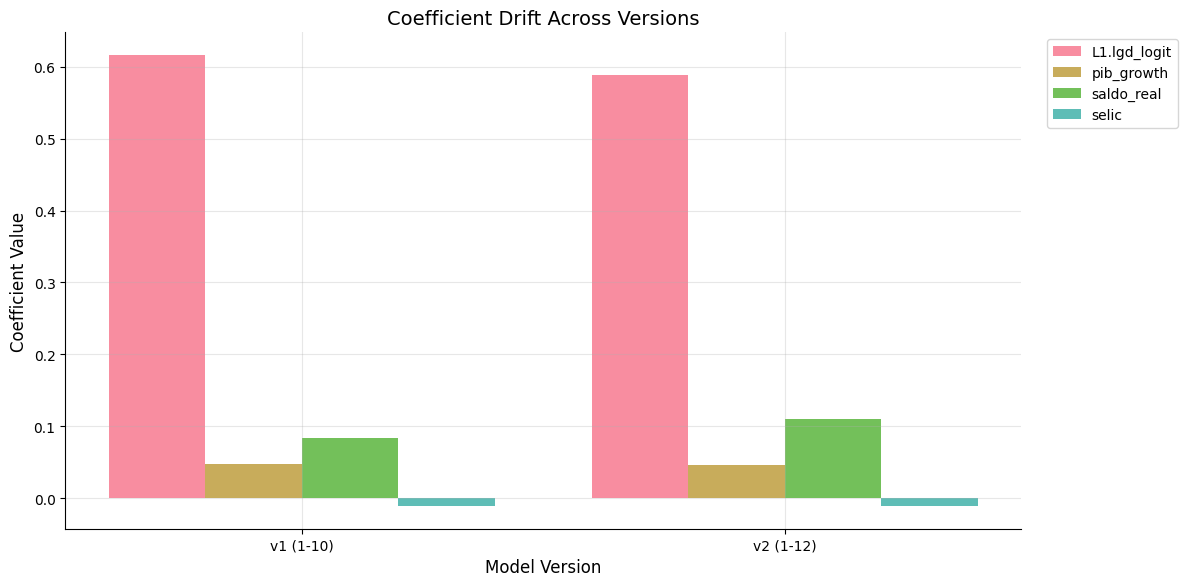

Figure saved.


In [13]:
# Step 5: Plot coefficient evolution across registered versions
version_data = [
    {"version": vt["version"] + f" ({vt['month_range']})", "params": vt["params"]}
    for vt in version_tracker
]

fig = plot_coefficient_drift(
    version_data,
    save_path=FIGURES_DIR / "05_ex3_coefficient_evolution.png",
)
plt.show()
print("Figure saved.")

In [14]:
# Step 6: Summary table
rows = []
for vt in version_tracker:
    row = {
        "Version": vt["version"],
        "Months": vt["month_range"],
        "Obs": vt["nobs"],
    }
    row.update(vt["params"])
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index("Version")
print("Coefficient Evolution Summary")
print("=" * 80)
print(df_summary.to_string(float_format="{:.4f}".format))

Coefficient Evolution Summary
        Months   Obs  L1.lgd_logit  saldo_real  pib_growth   selic
Version                                                           
v1        1-10  1600        0.6163      0.0840      0.0470 -0.0111
v2        1-12  2000        0.5882      0.1101      0.0455 -0.0104


In [15]:
# Stability analysis: coefficient of variation across versions
param_cols = [c for c in df_summary.columns if c not in ["Months", "Obs"]]
stability = pd.DataFrame(
    {
        "Mean": df_summary[param_cols].mean(),
        "Std": df_summary[param_cols].std(),
        "CV (%)": (df_summary[param_cols].std() / df_summary[param_cols].mean().abs() * 100),
        "Min": df_summary[param_cols].min(),
        "Max": df_summary[param_cols].max(),
    }
)

print("Coefficient Stability Report")
print("=" * 70)
print(stability.to_string(float_format="{:.4f}".format))
print()
print("Interpretation:")
print("  CV < 5%:  Very stable")
print("  CV 5-15%: Moderately stable")
print("  CV > 15%: Unstable — investigate")
for param in param_cols:
    cv = stability.loc[param, "CV (%)"]
    label = "STABLE" if cv < 5 else ("MODERATE" if cv < 15 else "UNSTABLE")
    print(f"  {param:20s}: CV = {cv:.1f}% -> {label}")

Coefficient Stability Report
                Mean    Std  CV (%)     Min     Max
L1.lgd_logit  0.6023 0.0199  3.3081  0.5882  0.6163
saldo_real    0.0970 0.0185 19.0504  0.0840  0.1101
pib_growth    0.0462 0.0011  2.3749  0.0455  0.0470
selic        -0.0107 0.0005  4.3651 -0.0111 -0.0104

Interpretation:
  CV < 5%:  Very stable
  CV 5-15%: Moderately stable
  CV > 15%: Unstable — investigate
  L1.lgd_logit        : CV = 3.3% -> STABLE
  saldo_real          : CV = 19.1% -> UNSTABLE
  pib_growth          : CV = 2.4% -> STABLE
  selic               : CV = 4.4% -> STABLE


**Key takeaways from the automated workflow**:

1. **Drift-based versioning** avoids storing redundant versions when the model is stable
2. **Coefficient tracking** across versions reveals which parameters are most sensitive to new data
3. **The CV (coefficient of variation)** provides a single-number summary of parameter stability
4. Parameters with high CV deserve investigation — they may indicate:
   - Weak identification (the data doesn't pin down the coefficient)
   - Structural breaks in the data
   - Multicollinearity with other variables
5. This workflow can be scheduled (e.g., via cron or Airflow) for fully automated model management